In [99]:
import os
import sys 
from torchvision import datasets
from torch.utils.data import DataLoader
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sys.path.append(os.path.abspath(os.path.join('..', 'train')))

In [100]:
from model import load_model, transform

In [101]:
ck_dir = 'kdef/'

In [102]:
for classes in os.listdir(ck_dir):
    class_files = os.path.join(ck_dir, classes)
    print(f'{classes}: {len([files for files in os.listdir(class_files)])}')

angry: 420
disgust: 416
fear: 419
happy: 419
neutral: 417
sad: 419
surprise: 418


In [103]:
ck_dataset = datasets.ImageFolder(root=ck_dir, transform=transform)
ck_loader = DataLoader(ck_dataset, batch_size=64, shuffle=False)

In [104]:
model_path = r'D:\StudyPath\GR1\Facial-Emotion-Regconition\checkpoint\best_model.pth'
model = load_model(model_path)

In [105]:
class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [106]:
all_preds = []
all_labels = []
correct = 0
total_samples = 0

with torch.no_grad():
    for inputs, labels in tqdm(ck_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        preds = torch.argmax(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (preds == labels).sum().item()
        total_samples += inputs.size(0)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
accuracy = correct / total_samples


100%|██████████| 46/46 [03:35<00:00,  4.68s/it]


In [107]:
print('Kdef accuracy: ',{accuracy})

Kdef accuracy:  {0.6086065573770492}


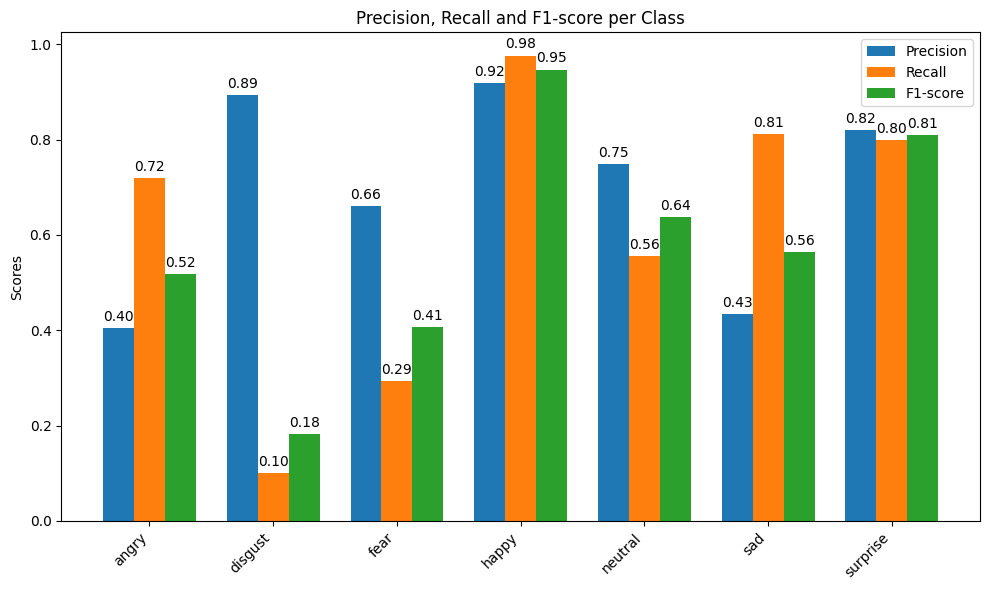

In [108]:
classes = np.arange(len(class_names))

precision = precision_score(all_labels, all_preds, average=None, labels=classes)
recall = recall_score(all_labels, all_preds, average=None, labels=classes)
f1 = f1_score(all_labels, all_preds, average=None, labels=classes)

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width, precision, width, label='Precision')
rects2 = ax.bar(x, recall, width, label='Recall')
rects3 = ax.bar(x + width, f1, width, label='F1-score')

ax.set_ylabel('Scores')
ax.set_title('Precision, Recall and F1-score per Class')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()


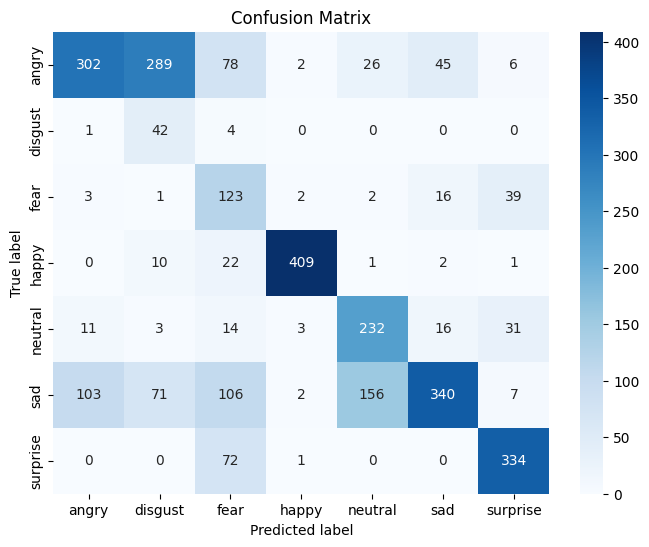

In [109]:
cm = confusion_matrix(np.array(all_preds), np.array(all_labels)) 

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()